# Steps should be performed :
 
## 1. Data Collection and Initial Exploration


● Dataset Link: Dataset

● Data Overview: Import the dataset and inspect it to understand the number of
features, labels, and any patterns.

● Check info, describe , Null values, column names, Duplicate columns or rows

● Check and Handle Null values if present

## 2.Data Preprocessing:

● Drop unwanted columns

● Handling Imbalance data

● Encoding Categorical Features: If there are any categorical features, encode
them using techniques like One-Hot Encoding,Label Encoding.

## 3. Exploratory Data Analysis (EDA)

● Check Data Distribution

● Correlations and Patterns: Use heatmaps or pair plots to analyze correlations
between features.

## 4. Visualisation:

● Perform visualisation on different columns in the dataset

● Must use: Boxplot, countplot, Heatmap, Pairplot, barplot,Histplot,Scatterplot

## 5. Feature Scaling

## 6. Model Selection & Fitting:

● Train Test split , Fit any 4 model suitable for the dataset and compare the
accuracies

## 7. Model Evaluation :

● Classification report, F1 SCORE, Accuracy score, Confusion matrix

# YOU CAN PERFORM ADDITIONAL STEPS ALSO.

## 1. Data Collection and Initial Exploration


● Dataset Link: Dataset

● Data Overview: Import the dataset and inspect it to understand the number of
features, labels, and any patterns.

● Check info, describe , Null values, column names, Duplicate columns or rows

● Check and Handle Null values if present


### Importing Libraries

In [78]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import pickle

### Data Overview: Import the dataset and inspect it to understand the number of features, labels, and any patterns.

In [79]:
df = pd.read_csv(r"C:\Users\aryan\OneDrive\Desktop\DS PROJECTS\DATA SCIENCE (PROJECT)\BREAST CANCER DETECTION\MAIN FILE\3722626-Breast_cancer_detection-20250114T060027Z-001(1)\Breast_cancer_detection\breast_cancer_data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Dataset Information

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Statistical Summary

In [81]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Column Names

In [82]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Check Duplicate Rows

In [83]:
df.duplicated().sum()

np.int64(0)

## Check Null Values

In [84]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

## 2.Data Preprocessing:

● Drop unwanted columns

● Handling Imbalance data

● Encoding Categorical Features: If there are any categorical features, encode
them using techniques like One-Hot Encoding,Label Encoding.


## Drop Unwanted Columns

In [85]:
df.drop(['id','Unnamed: 32'], axis = 1, inplace = True)

In this dataset:

- id → useless for prediction

- Unnamed: 32 → empty column

### Encode Target Variable

diagnosis

- M = Malignant

- B = Benign

In [86]:
from sklearn.preprocessing import LabelEncoder

In [87]:
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [88]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

● Check Data Distribution

● Correlations and Patterns: Use heatmaps or pair plots to analyze correlations
between features.

### Target Distribution

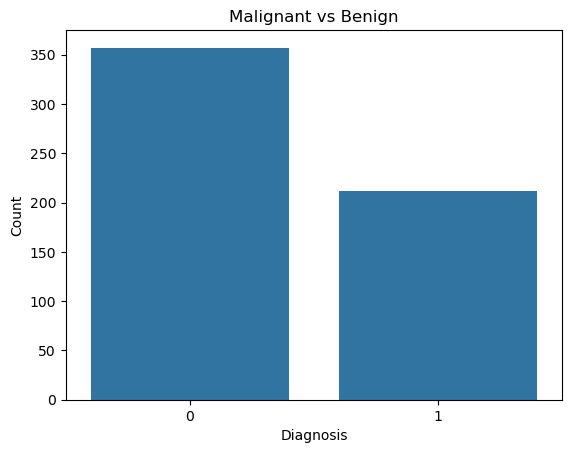

In [89]:
sns.countplot(x = 'diagnosis', data = df)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.title('Malignant vs Benign')
plt.show()

### Data Distribution

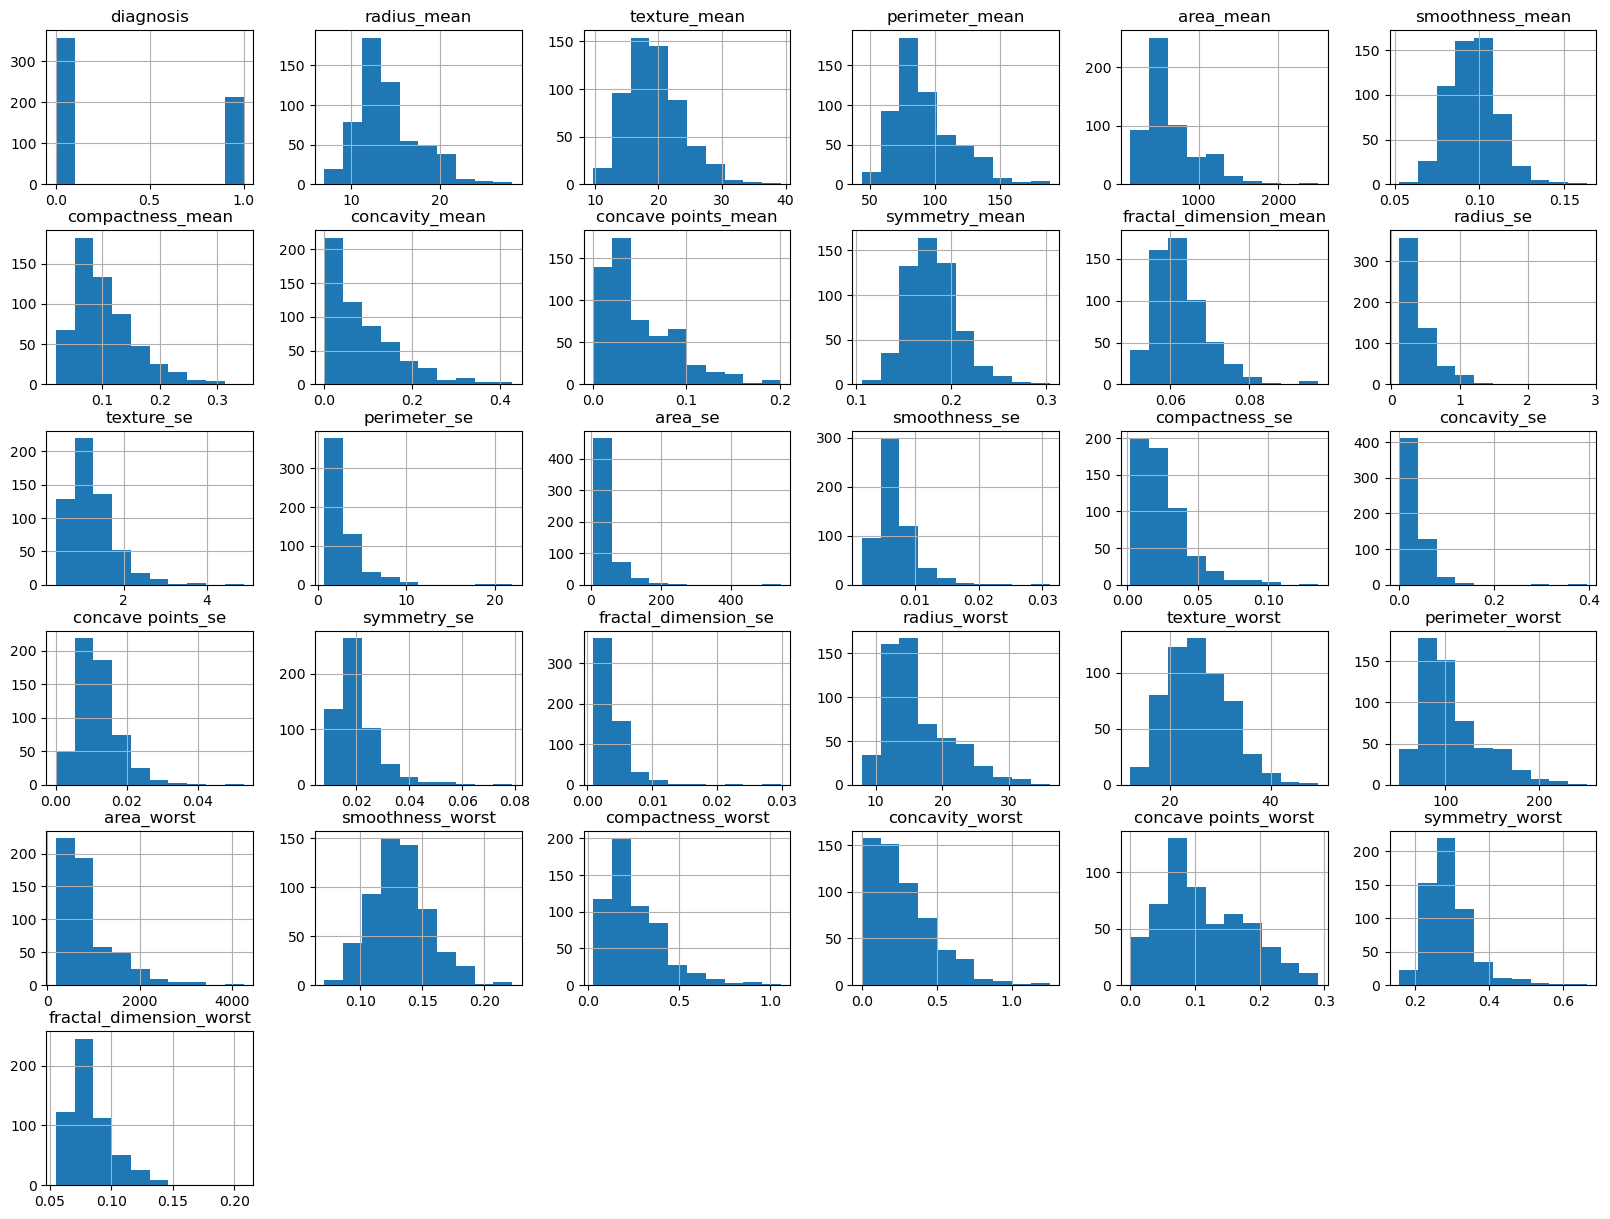

In [90]:
df.hist(figsize = (20 ,15))
plt.show()

### Heatmap

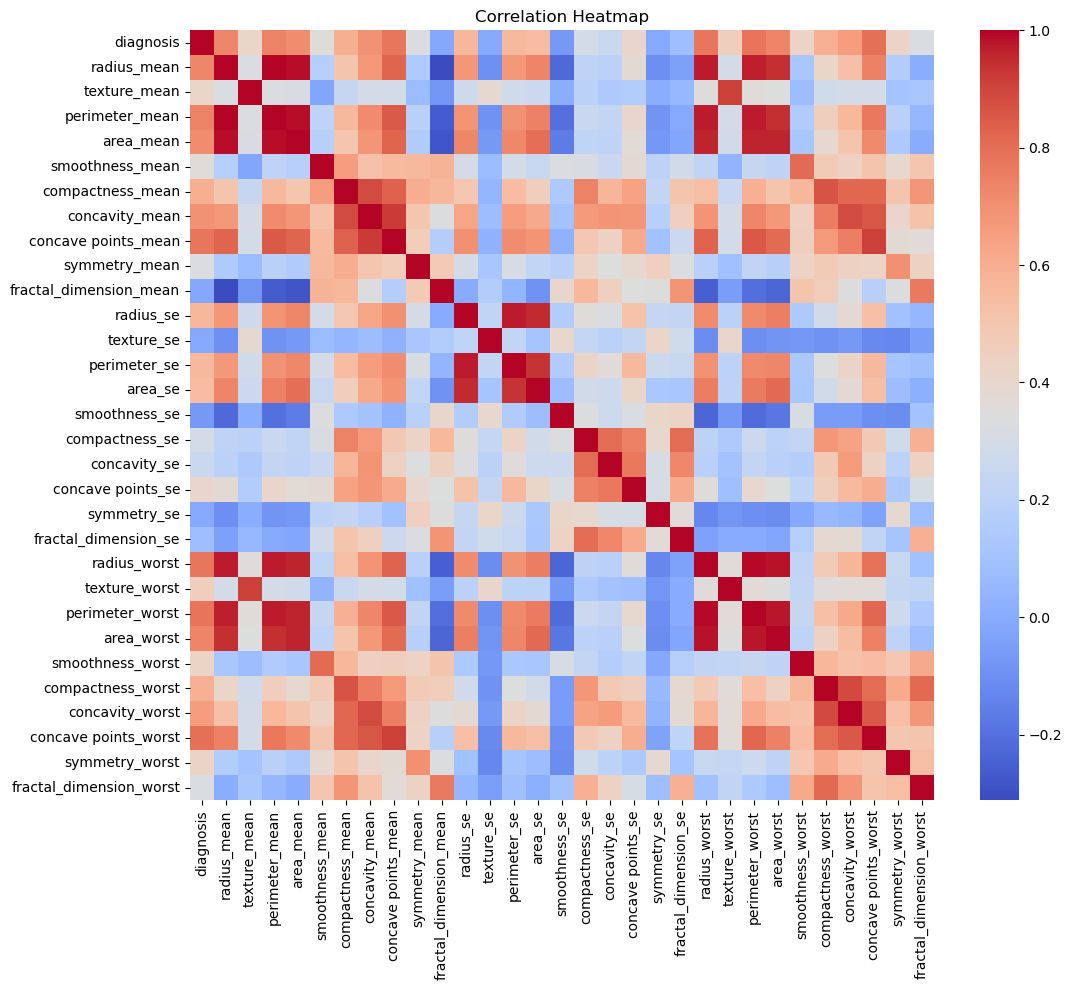

In [91]:
plt.figure(figsize = (12,10))

sns.heatmap(df.corr(), cmap = 'coolwarm')

plt.title('Correlation Heatmap')
plt.show()

Used for:

- Feature selection

- Detecting multicollinearity

### Pairplot

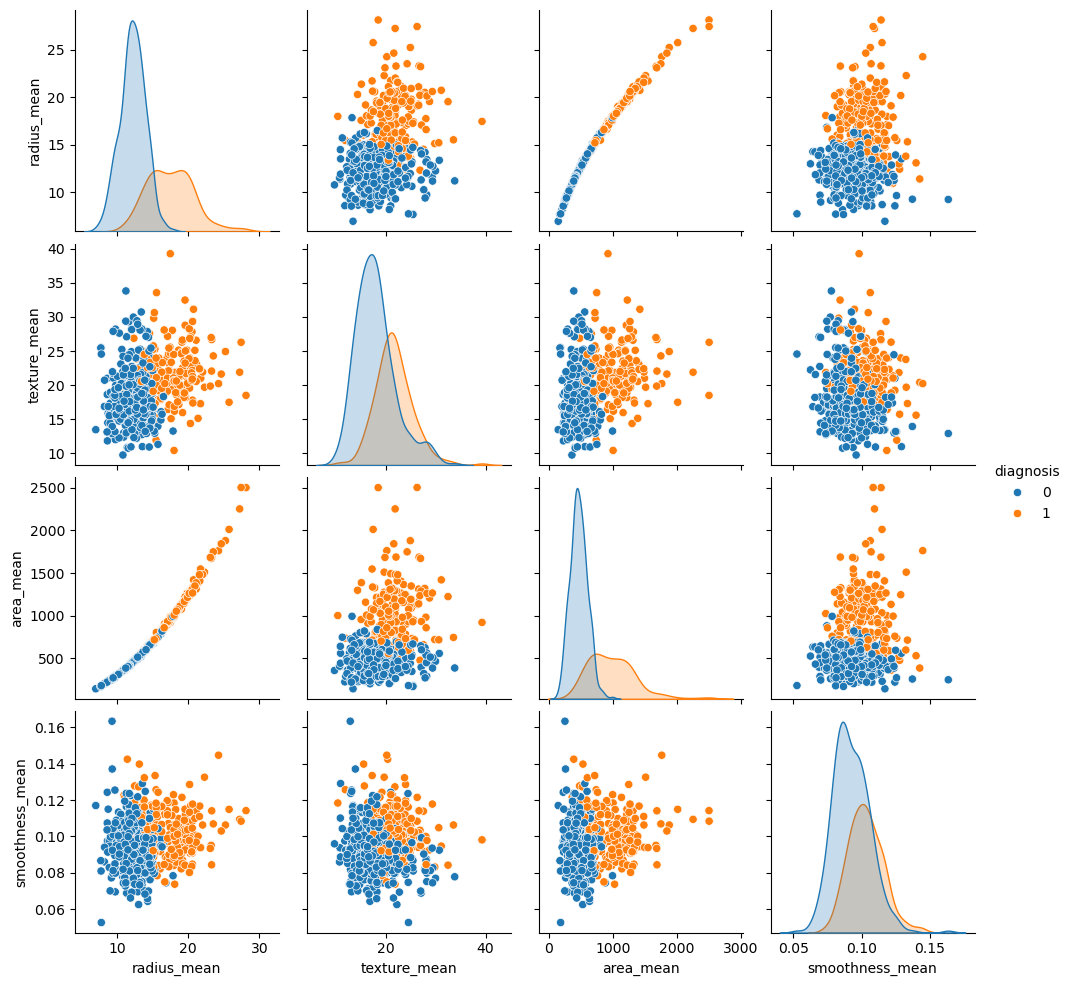

In [92]:
sns.pairplot(
    df[['diagnosis','radius_mean','texture_mean','area_mean','smoothness_mean']],
    hue='diagnosis'
)

plt.show()

This helps see:

- Class separation.

- Feature relationships.

## 4. Visualisation:

● Perform visualisation on different columns in the dataset

● Must use: Boxplot, countplot, Heatmap, Pairplot, barplot,Histplot,Scatterplot

###  Perform visualisation on different columns in the dataset

#### Boxplot

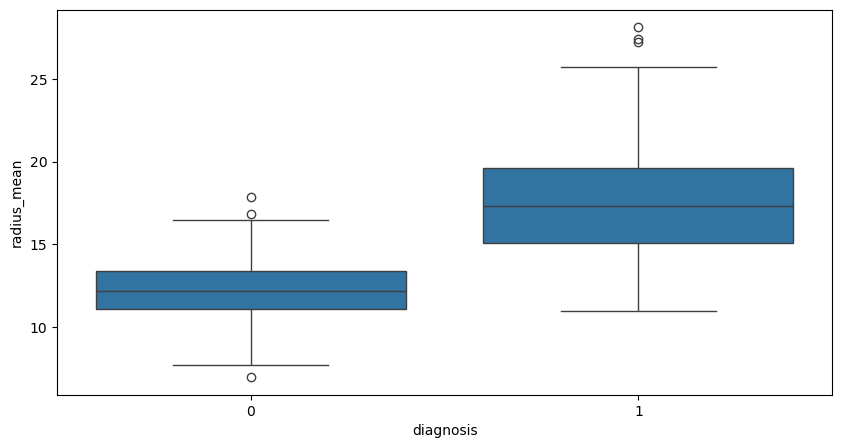

In [93]:
plt.figure(figsize = (10,5))
sns.boxplot(x = 'diagnosis', y = 'radius_mean', data = df)
plt.show()

## Checking Interquartile Range for Diagnosis

In [94]:
# Calculate Q1, Q3, and IQR
Q1 = df['diagnosis'].quantile(0.25)
Q3 = df['diagnosis'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')

Q1: 0.0
Q3: 1.0
IQR: 1.0


#### Histogram

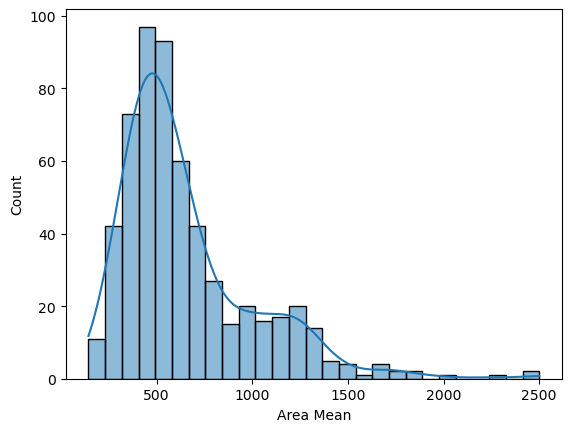

In [95]:
sns.histplot(df['area_mean'], kde = True)
plt.xlabel('Area Mean')
plt.ylabel('Count')
plt.show()

#### Histogram

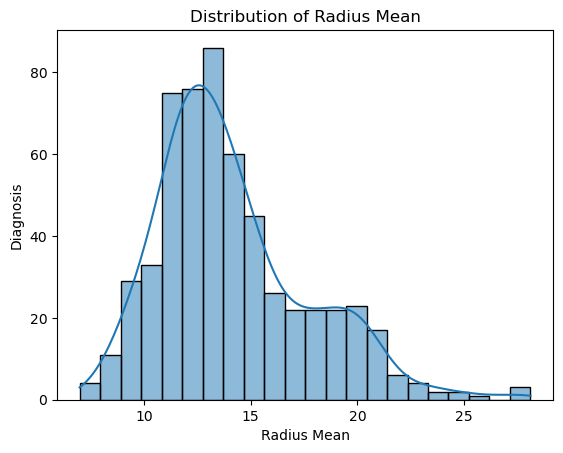

In [96]:
sns.histplot(df["radius_mean"], kde=True)
plt.title("Distribution of Radius Mean")
plt.xlabel('Radius Mean')
plt.ylabel('Diagnosis')
plt.show()

#### Scatterplot

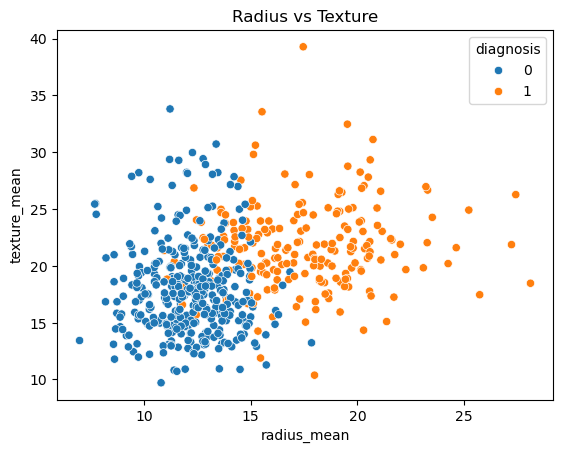

In [97]:
sns.scatterplot(
    x = 'radius_mean',
    y = 'texture_mean',
    hue = 'diagnosis',
    data = df
)

plt.title('Radius vs Texture')
plt.show()

- Helps identify separability between classes.

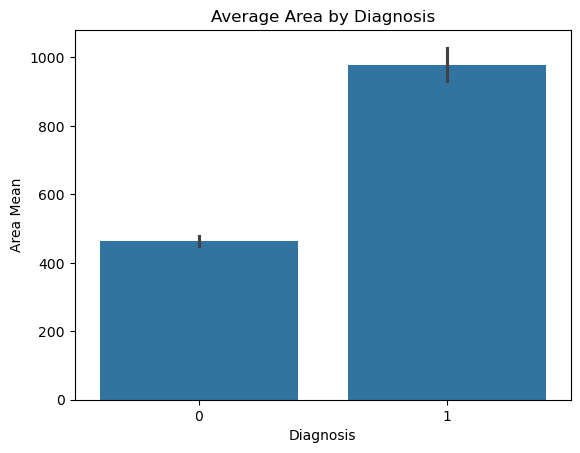

In [98]:
sns.barplot(x = 'diagnosis', y = 'area_mean', data = df)
plt.title("Average Area by Diagnosis")
plt.xlabel('Diagnosis')
plt.ylabel('Area Mean')
plt.show()

- Shows average difference between classes.

### Violin Plot

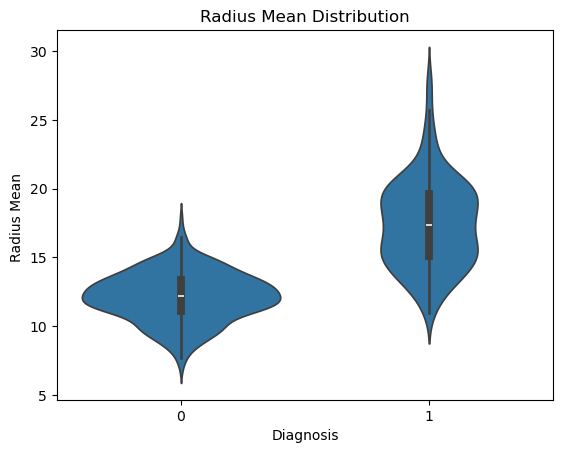

In [99]:
sns.violinplot(x = 'diagnosis', y = 'radius_mean', data = df)
plt.title("Radius Mean Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Radius Mean ")
plt.show()

#### Feature Correlation with Target 

In [100]:
corr = df.corr()

corr['diagnosis'].sort_values(ascending = False)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

#### Understanding the important features with the help of visualization

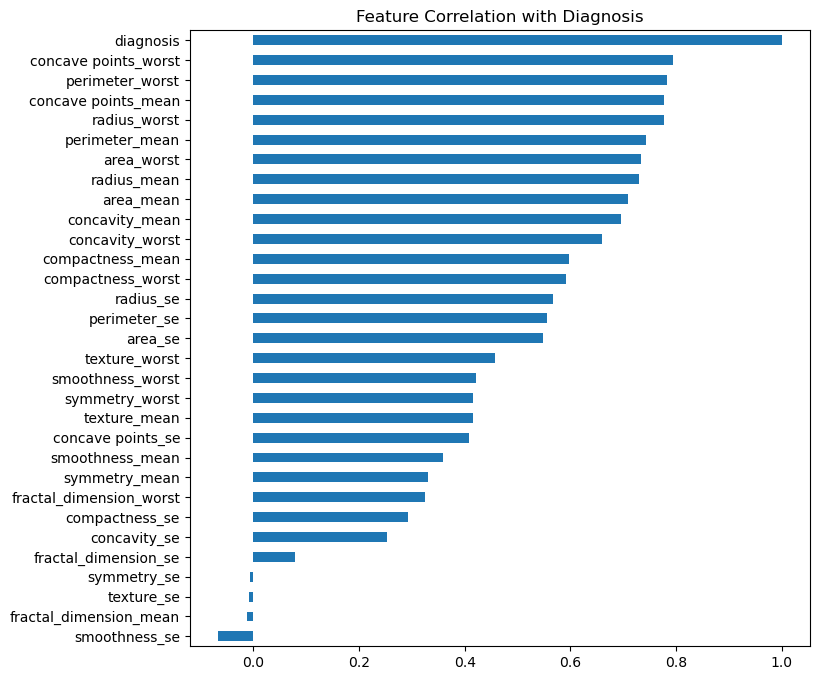

In [101]:
corr['diagnosis'].sort_values().plot(kind = 'barh', figsize = (8,8))
plt.title('Feature Correlation with Diagnosis')
plt.show()

### Multiple Feature Distributions

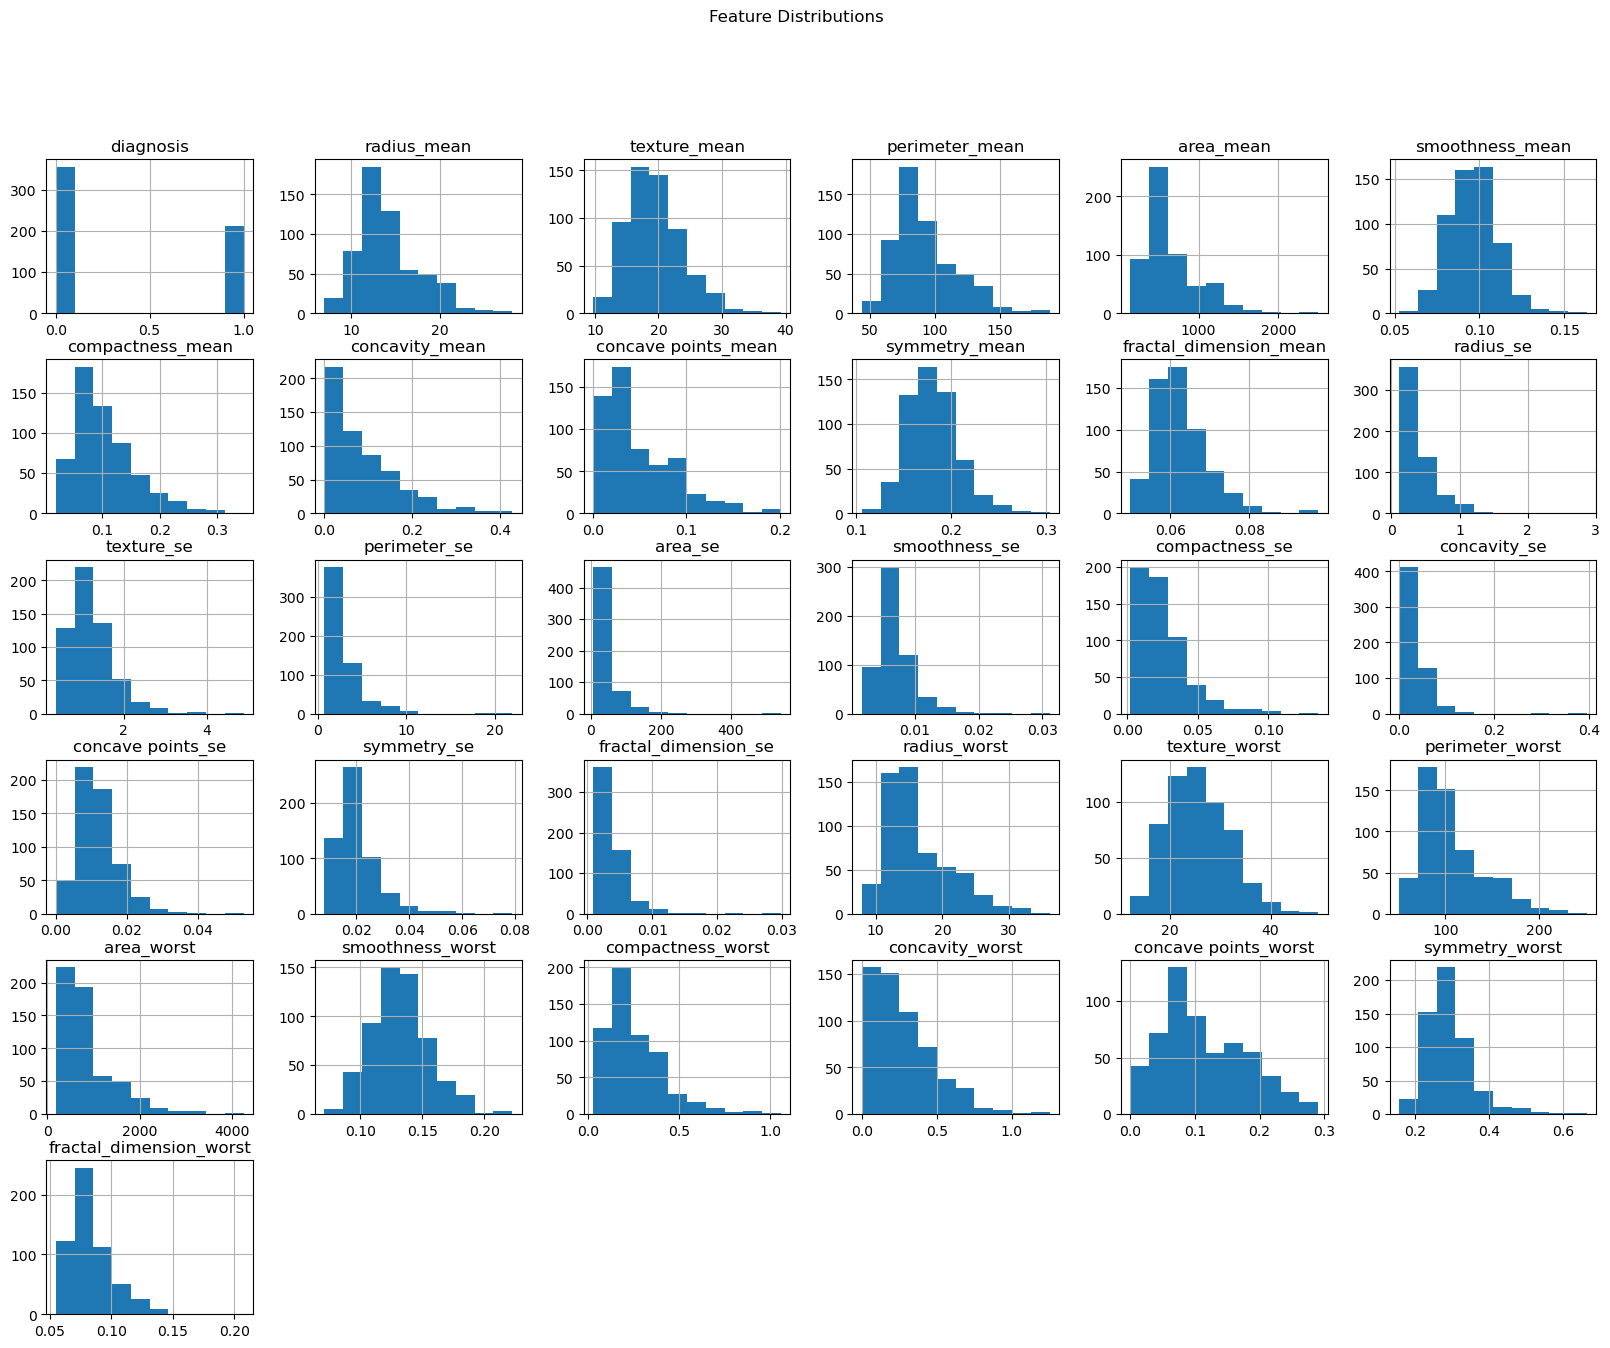

In [102]:
df.hist(figsize = (20,15))
plt.suptitle('Feature Distributions')
plt.show()

## 5. Feature Scaling

#### Separate Features and Target

In [103]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

#### Remove unnecessary or highly correlated features.

In [104]:
corr = df.corr()

corr['diagnosis'].sort_values(ascending=False)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

## 6. Model Selection & Fitting:

● Train Test split , Fit any 4 model suitable for the dataset and compare the
accuracies

## Train-Test Split

In [105]:
from sklearn.model_selection import train_test_split

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

##### Using Standard Scalar

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 7. Model Evaluation :

● Classification report, F1 SCORE, Accuracy score, Confusion matrix



# Train Logistic Regression Model

In [108]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter = 10000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

- max_iter=10000 is used because sometimes Logistic Regression needs more iterations to converge.

### Prediction

In [109]:
# Test prediction
y_pred_test_lr = log_model.predict(X_test)

# Training prediction
y_pred_train_lr = log_model.predict(X_train)

### Accuracy Score

In [111]:
train_accuracy = accuracy_score(y_train,y_pred_train_lr)
test_accuracy = accuracy_score(y_test,y_pred_test_lr)

print('Training Accuracy:', train_accuracy * 100)
print('Testing Accuracy:', test_accuracy * 100)

Training Accuracy: 98.68131868131869
Testing Accuracy: 97.36842105263158


# Logistics Regression Accuracy

In [161]:
logistic_test_accuracy = accuracy_score(y_test, y_pred_test_lr)

print("Logistic Regression Accuracy:", logistic_test_accuracy * 100)

Logistic Regression Accuracy: 97.36842105263158


### Overfitting / Underfitting Check

In [112]:
if train_accuracy > test_accuracy + 0.05:
    print('Model is Overfitting')

elif train_accuracy < test_accuracy:
    print('Model is Underfitting')

else:
    print('Model is Balanced')

Model is Balanced


## Classification Report

In [114]:
print(classification_report(y_test, y_pred_test_lr))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Confusion Matrix

In [115]:
cm = confusion_matrix(y_test, y_pred_test_lr)

print(cm)

[[70  1]
 [ 2 41]]


### Visualization:

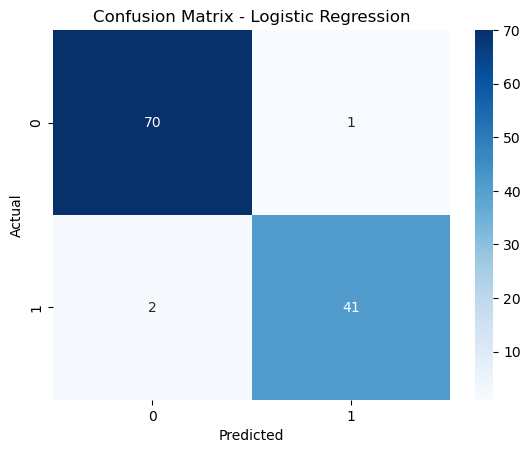

In [118]:
sns.heatmap(cm, annot = True, cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### F1 Score

In [120]:
f1 = f1_score(y_test, y_pred_test_lr)

print("F1 Score:", f1 * 100)

F1 Score: 96.47058823529412


### Logistics Regression Coefficients (Feature Importance)

In [121]:
feature_importance = pd.Series(
    log_model.coef_[0],
    index = X.columns
)

print(feature_importance.sort_values(ascending = False))

texture_worst              1.350606
radius_se                  1.268178
symmetry_worst             1.208200
concave points_mean        1.119804
concavity_worst            0.943053
area_se                    0.907186
radius_worst               0.879840
area_worst                 0.841846
concavity_mean             0.801458
concave points_worst       0.778217
perimeter_se               0.610583
perimeter_worst            0.589453
smoothness_worst           0.544170
area_mean                  0.465210
radius_mean                0.431904
perimeter_mean             0.393432
texture_mean               0.387326
smoothness_se              0.313307
concave points_se          0.311300
fractal_dimension_worst    0.157414
smoothness_mean            0.071667
compactness_worst         -0.016110
fractal_dimension_mean    -0.075921
concavity_se              -0.175275
texture_se                -0.188877
symmetry_mean             -0.236119
symmetry_se               -0.500425
compactness_mean          -0

#### Visualization:

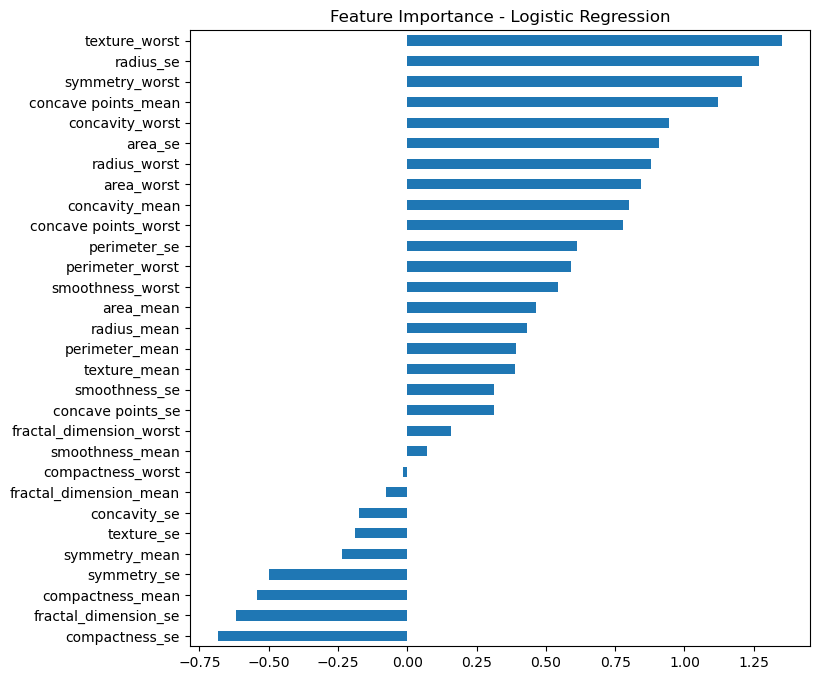

In [122]:
feature_importance.sort_values().plot(kind = 'barh', figsize = (8,8))

plt.title('Feature Importance - Logistic Regression')

plt.show()

# Train Decision Tree Model

In [123]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Prediction

In [124]:
# Prediction on test data
y_pred_test_dt = dt_model.predict(X_test)

# Prediction on training data
y_pred_train_dt = dt_model.predict(X_train)

### Accuracy Score

In [126]:
train_accuracy = accuracy_score(y_train, y_pred_train_dt)
test_accuracy = accuracy_score(y_test, y_pred_test_dt)

print("Training Accuracy:", train_accuracy * 100)
print("Testing Accuracy:", test_accuracy * 100)

Training Accuracy: 100.0
Testing Accuracy: 94.73684210526315


# Decision Tree Accuracy

In [163]:
dt_test_accuracy = accuracy_score(y_test, y_pred_test_dt)

print("Decision Tree Accuracy:", dt_test_accuracy * 100)

Decision Tree Accuracy: 94.73684210526315


### Check Overfitting / Underfitting

In [127]:
if train_accuracy > test_accuracy + 0.05:
    print('Model is Overfitting')

elif train_accuracy < test_accuracy:
    print('Model is Underfitting')

else:
    print('Model is Balanced')

Model is Overfitting


### Classification Report

In [128]:
print(classification_report(y_test, y_pred_test_dt))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### Confusion Matrix

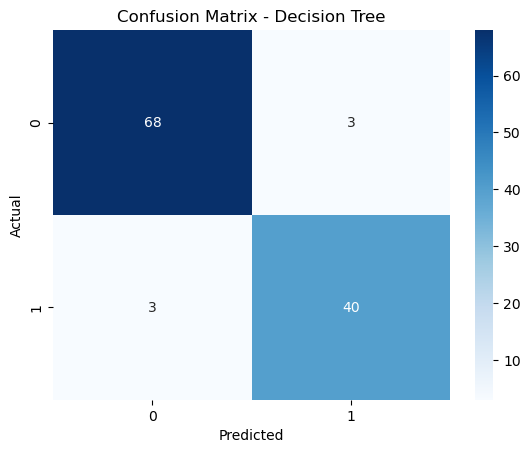

In [129]:
cm = confusion_matrix(y_test, y_pred_test_dt)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Feature Importance

In [130]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

print(feature_importance)

concave points_mean        0.691420
concave points_worst       0.065651
texture_mean               0.058478
radius_worst               0.052299
perimeter_worst            0.051494
fractal_dimension_se       0.018554
texture_worst              0.017445
concave points_se          0.015931
area_se                    0.011983
smoothness_worst           0.009233
concavity_se               0.006276
smoothness_se              0.001237
perimeter_mean             0.000000
area_mean                  0.000000
perimeter_se               0.000000
texture_se                 0.000000
radius_se                  0.000000
fractal_dimension_mean     0.000000
concavity_mean             0.000000
symmetry_mean              0.000000
smoothness_mean            0.000000
compactness_mean           0.000000
radius_mean                0.000000
compactness_se             0.000000
symmetry_se                0.000000
area_worst                 0.000000
compactness_worst          0.000000
concavity_worst            0

#### Visualization:

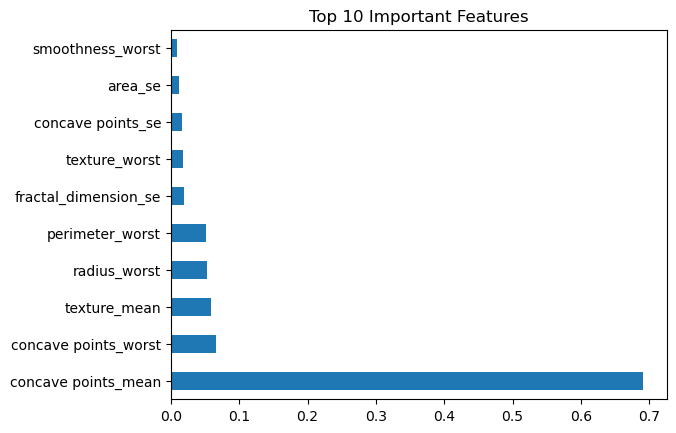

In [131]:
feature_importance.head(10).plot(kind = 'barh')

plt.title('Top 10 Important Features')

plt.show()

# Train Random Forest Model

In [132]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Prediction

In [133]:
# Test prediction
y_pred_test_rf = rf_model.predict(X_test)

# Training prediction
y_pred_train_rf = rf_model.predict(X_train)

### Accuracy Score

In [139]:
train_accuracy = accuracy_score(y_train, y_pred_train_rf)
test_accuracy = accuracy_score(y_test, y_pred_test_rf)

print('Training Accuracy:', train_accuracy * 100)
print('Testing Accuracy:', test_accuracy * 100)

Training Accuracy: 100.0
Testing Accuracy: 96.49122807017544


# Random Forest Accuracy

In [165]:
rf_test_accuracy = accuracy_score(y_test, y_pred_test_rf)

print("Random Forest Accuracy:", rf_test_accuracy * 100)

Random Forest Accuracy: 96.49122807017544


### Check Overfitting / Underfitting

In [143]:
if train_accuracy > test_accuracy + 0.05:
    print('Model is Overfitting')

elif train_accuracy < test_accuracy:
    print('Model is Underfitting')

else:
    print('Model is Balanced')

Model is Balanced


### Classification Report

In [144]:
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Confusion Matrix

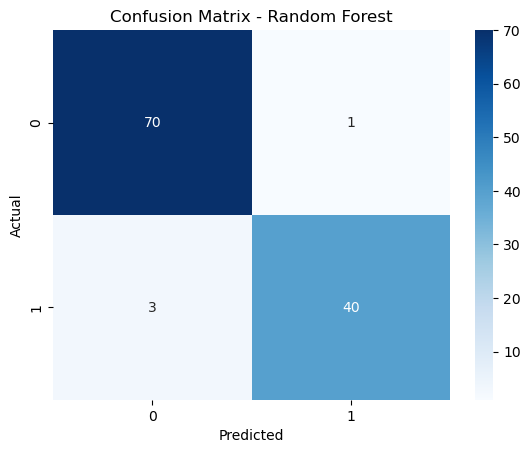

In [146]:
cm = confusion_matrix(y_test, y_pred_test_rf)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

#### Feature Importance 

In [147]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

print(feature_importance)

area_worst                 0.153892
concave points_worst       0.144663
concave points_mean        0.106210
radius_worst               0.077987
concavity_mean             0.068001
perimeter_worst            0.067115
perimeter_mean             0.053270
radius_mean                0.048703
area_mean                  0.047555
concavity_worst            0.031802
area_se                    0.022407
texture_worst              0.021749
compactness_worst          0.020266
radius_se                  0.020139
compactness_mean           0.013944
texture_mean               0.013591
perimeter_se               0.011303
smoothness_worst           0.010644
symmetry_worst             0.010120
concavity_se               0.009386
smoothness_mean            0.007285
fractal_dimension_se       0.005321
compactness_se             0.005253
fractal_dimension_worst    0.005210
texture_se                 0.004724
smoothness_se              0.004271
symmetry_se                0.004018
fractal_dimension_mean     0

#### Visualization:

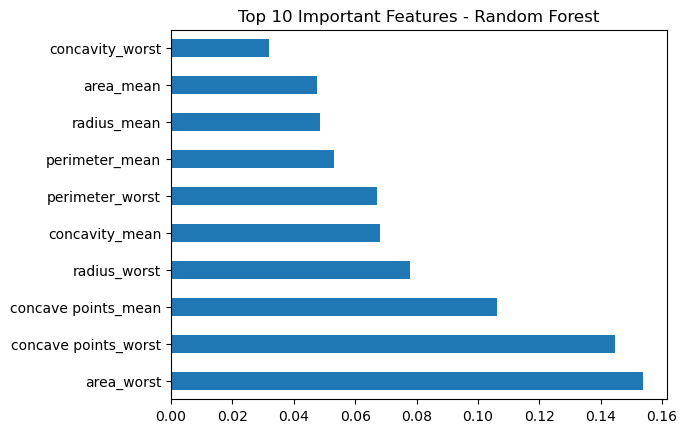

In [148]:
feature_importance.head(10).plot(kind = 'barh')

plt.title('Top 10 Important Features - Random Forest')

plt.show()

# Train SVM Model

In [149]:
svm_model = SVC()

svm_model.fit(X_train, y_train)

SVC()

### Prediciton

In [150]:
# Prediction on test data
y_pred_test_svc = svm_model.predict(X_test)

# Prediction on training data
y_pred_train_svc = svm_model.predict(X_train)

### Accuracy Score

In [152]:
train_accuracy = accuracy_score(y_train, y_pred_train_svc)
test_accuracy = accuracy_score(y_test, y_pred_test_svc)

print("Training Accuracy:", train_accuracy * 100)
print("Testing Accuracy:", test_accuracy * 100)

Training Accuracy: 98.9010989010989
Testing Accuracy: 98.24561403508771


# SVM Accuracy

In [167]:
svm_test_accuracy = accuracy_score(y_test, y_pred_test_svc)

print("SVM Accuracy:", svm_test_accuracy * 100)

SVM Accuracy: 98.24561403508771


### Check Overfitting / Underfitting

In [153]:
if train_accuracy > test_accuracy + 0.05:
    print('Model is Overfitting')

elif train_accuracy < test_accuracy:
    print('Model is Underfitting')

else:
    print('Model is Balanced')

Model is Balanced


### Classification Report

In [155]:
print(classification_report(y_test, y_pred_test_svc))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Confusion Matrix

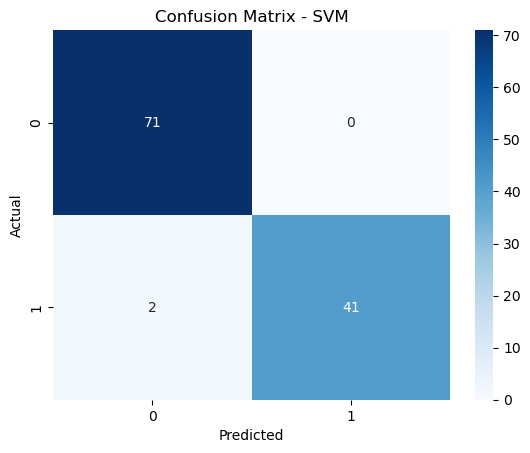

In [158]:
cm = confusion_matrix(y_test, y_pred_test_svc)

sns.heatmap(cm, annot = True, cmap = 'Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')

plt.show()

# Model Comparison Table

In [171]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Fores','SVM'],
    'Accuracy': [
        logistic_test_accuracy * 100,
        dt_test_accuracy * 100,
        rf_test_accuracy * 100,
        svm_test_accuracy * 100
    ]
})

comparison.sort_values(by = 'Accuracy', ascending = False)

,Model,Accuracy
3,SVM,98.245614
0,Logistic Regression,97.368421
2,Random Fores,96.491228
1,Decision Tree,94.736842


Key Insights

- The dataset contains features computed from digitized images of breast cell nuclei used to classify tumors as malignant (cancerous) or benign (non-cancerous).

- The dataset was explored and cleaned by checking null values, duplicates, and unnecessary columns.

- Columns such as id and Unnamed: 32 were removed because they do not contribute to prediction.

- The target variable diagnosis was encoded into numeric values where Malignant = 1 and Benign = 0.

- Exploratory Data Analysis showed that features related to tumor size, shape, and texture strongly influence the diagnosis.

- Visualization techniques such as histograms, boxplots, scatterplots, pairplots, and heatmaps helped identify patterns and correlations between features.

- The correlation heatmap indicated that several features such as radius_mean, perimeter_mean, area_mean, and concavity_mean are strongly correlated with the diagnosis.

- Feature scaling was applied using StandardScaler to normalize the feature values and improve model performance.

- Four machine learning models were trained and evaluated:

            - Logistic Regression

            - Decision Tree

            - Random Forest

            - Support Vector Machine (SVM)

- Model comparison showed that SVM achieved the highest accuracy of 98.24%, making it the best-performing model.

# Conclusion

- The main objective of this project was to build a machine learning model that can predict whether a breast tumor is malignant or benign based on diagnostic measurements.

- After performing data preprocessing, exploratory data analysis, feature engineering, and model training, four classification models were evaluated.

- Among the tested models, Support Vector Machine (SVM) provided the highest prediction accuracy (98.24%).

- The results demonstrate that machine learning algorithms can effectively assist in breast cancer detection using medical diagnostic data.

- Such predictive models can help in early detection and decision support, which is important for improving treatment outcomes.